In [1]:
import h5py
import numpy as np

PR = 0  # Change as needed
last_n = 78000  # number of last time steps to read

# File paths
u_file = f"/data92/PeterChang/Dycore_data/PR{PR}/u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = f"/data92/PeterChang/Dycore_data/PR{PR}/v/PR{PR}_500_20000day_v_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"
w_file = f"/data92/PeterChang/Dycore_data/PR{PR}/w/PR{PR}_500_20000day_w_6hourly.h5"
p_file = f"/data92/PeterChang/Dycore_data/PR{PR}/p/PR{PR}_500_20000day_p_6hourly.h5"
ps_file = f"/data92/PeterChang/Dycore_data/PR{PR}/ps/PR{PR}_500_20000day_ps_6hourly.h5"


# Read only the last `last_n` time steps of the main dataset in each file
def read_last_timesteps(file_path, last_n):
    with h5py.File(file_path, 'r') as f:
        # Assume there's only one dataset or we know the key
        data_key = list(f.keys())[0]  # e.g., 'u'
        dset = f[data_key]
        total_time = dset.shape[0]
        return dset[-last_n:, ...]  # last 5000 time steps

# Load data slices
u_last = read_last_timesteps(u_file, last_n)
v_last = read_last_timesteps(v_file, last_n)
t_last = read_last_timesteps(t_file, last_n)
w_last = read_last_timesteps(w_file, last_n)
p_last = read_last_timesteps(p_file, last_n)  # shape likely (time, y, x)
ps_last = read_last_timesteps(ps_file, last_n)  # shape likely (time, y, x)


# Confirm shapes (optional)
print("u:", u_last.shape)
print("v:", v_last.shape)
print("t:", t_last.shape)
print("w:", w_last.shape)
print("p:", p_last.shape)
print("ps:", ps_last.shape)



u: (78000, 20, 64, 128)
v: (78000, 20, 64, 128)
t: (78000, 20, 64, 128)
w: (78000, 20, 64, 128)
p: (78000, 20, 64, 128)
ps: (78000, 1, 64, 128)


In [2]:
# Confirm shapes (optional)
print("u:", u_last.shape)
print("v:", v_last.shape)
print("t:", t_last.shape)
print("w:", w_last.shape)
print("ps:", ps_last.shape)

u: (78000, 20, 64, 128)
v: (78000, 20, 64, 128)
t: (78000, 20, 64, 128)
w: (78000, 20, 64, 128)
ps: (78000, 1, 64, 128)


In [3]:
# read PC1 positive and negative time index
with h5py.File("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_positive_1std_PR0.h5", 'r') as F:
    pc1_pos_idx = F['time_idx_pos'][0]  # (N,) array of integers

with h5py.File("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_negative_1std_PR0.h5", 'r') as F:
    pc1_neg_idx = F['time_idx_neg'][0]  # (N,) array of integers


In [10]:
pc1_pos_idx.shape

(12482,)

In [68]:
import sys
import importlib

sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/")
import climate
importlib.reload(climate)  # ← 強制重新載入

<module 'climate' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/climate.py'>

In [69]:
y = np.linspace(-90, 90, 64)
p1d = p_last[pc1_pos_idx].mean(axis=(0,2,3))

ep1_pos, ep2_pos, div1, dthdp, vptp, vertEddy = climate.ComputeEPfluxDiv(y, p1d / 100, u_last[pc1_pos_idx], v_last[pc1_pos_idx], t_last[pc1_pos_idx])

In [70]:
vertEddy.shape

(12482, 20, 64)

In [71]:
np.nanmin(vertEddy)

-9130912.0

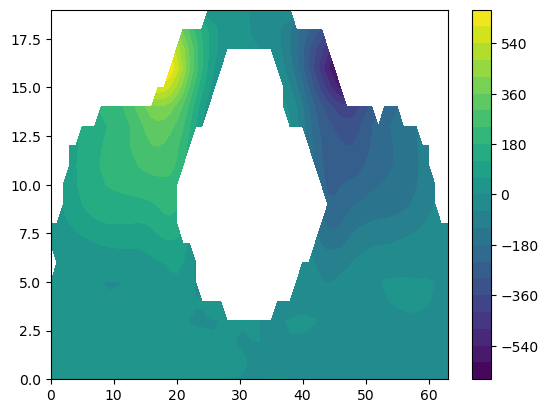

In [74]:
plt.figure()
plt.contourf(vertEddy.mean(axis=0), levels=21)
plt.colorbar()
print()

In [21]:
ep1_pos.shape

(12482, 20, 64)

In [22]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

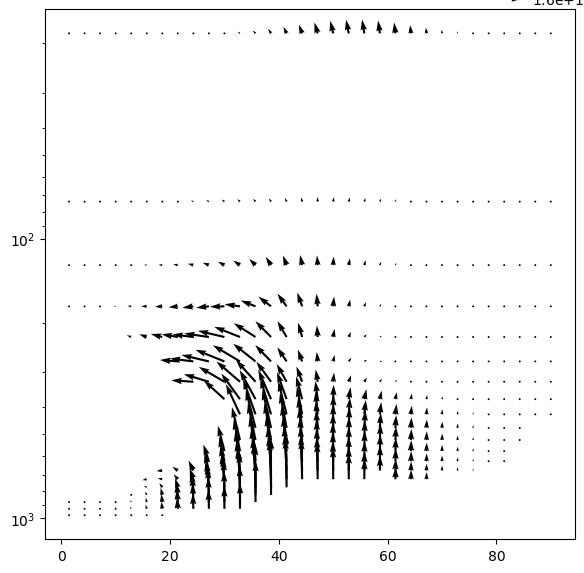

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1)
set_size(5.3,5.3,ax)
_ = climate.PlotEPfluxArrows(y[32:], p1d[:]/100, ep1_pos[:,:,32:].mean(axis=0), ep2_pos[:,:,32:].mean(axis=0), fig, ax, yscale="log")

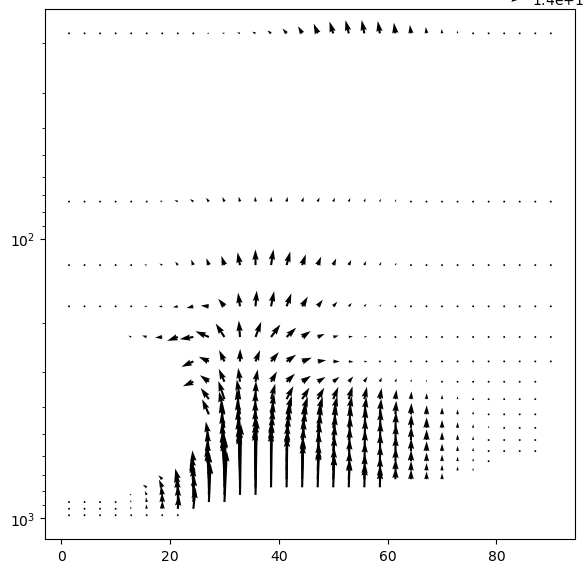

In [27]:
y = np.linspace(-90, 90, 64)
p1d = p_last[pc1_pos_idx].mean(axis=(0,2,3))

ep1, ep2, div1, dthdp, vptp = climate.ComputeEPfluxDiv(y, p1d / 100, u_last[pc1_neg_idx], v_last[pc1_neg_idx], t_last[pc1_neg_idx])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1)
set_size(5.3,5.3,ax)
_ = climate.PlotEPfluxArrows(y[32:], p1d[:]/100, ep1[:,:,32:].mean(axis=0), ep2[:,:,32:].mean(axis=0), fig, ax, yscale="log")

In [19]:
# save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR{PR}_positive.npz"
# np.savez(save_path, ep1=ep1, ep2=ep2, y=y, p1d=p1d)

In [54]:
f = np.load("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR0_positive.npz")
ep1_PR0_pos = f["ep1"][:]
ep2_PR0_pos = f["ep2"][:]

f = np.load("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR0_negative.npz")
ep1_PR0_neg = f["ep1"][:]
ep2_PR0_neg = f["ep2"][:]

f = np.load("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR50_positive.npz")
ep1_PR50_pos = f["ep1"][:]
ep2_PR50_pos = f["ep2"][:]

f = np.load("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR50_negative.npz")
ep1_PR50_neg = f["ep1"][:]
ep2_PR50_neg = f["ep2"][:]
y = f["y"][:]
p1d = f["p1d"][:]


/tmp/ipykernel_312845/2534718029.py:8: RuntimeWarning: Mean of empty slice
  - (np.nanmean(ep1_PR0_pos[:,:,32:], axis=0) - np.nanmean(ep1_PR0_neg[:,:,32:], axis=0)),
/tmp/ipykernel_312845/2534718029.py:10: RuntimeWarning: Mean of empty slice
  - (np.nanmean(ep2_PR0_pos[:,:,32:], axis=0) - np.nanmean(ep2_PR0_neg[:,:,32:], axis=0)),


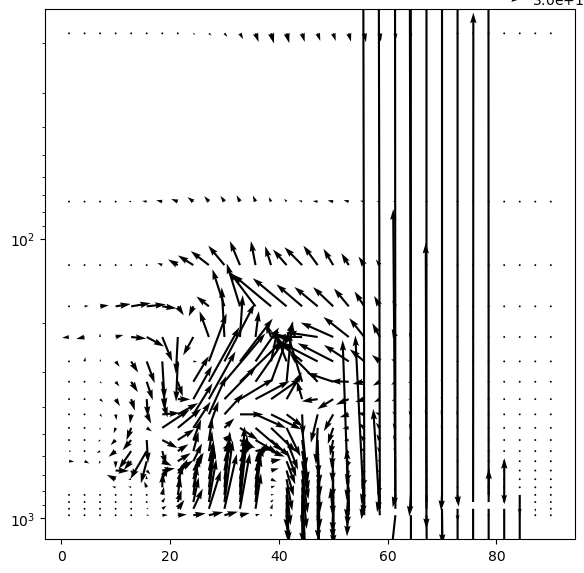

In [55]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1)
set_size(5.3,5.3,ax)
_ = climate.PlotEPfluxArrows(y[32:], p1d[:]/100, 
                         # np.nanmean(ep1_PR0_neg[:,:,32:], axis=0), 
                         # np.nanmean(ep2_PR0_neg[:,:,32:], axis=0),
                         np.nanmean(ep1_PR50_pos[:,:,32:], axis=0) - np.nanmean(ep1_PR50_neg[:,:,32:], axis=0)
                         - (np.nanmean(ep1_PR0_pos[:,:,32:], axis=0) - np.nanmean(ep1_PR0_neg[:,:,32:], axis=0)), 
                         np.nanmean(ep2_PR50_pos[:,:,32:], axis=0) - np.nanmean(ep2_PR50_neg[:,:,32:], axis=0)
                         - (np.nanmean(ep2_PR0_pos[:,:,32:], axis=0) - np.nanmean(ep2_PR0_neg[:,:,32:], axis=0)), 
                         fig, ax, yscale="log", scale=3e15)

/tmp/ipykernel_312845/367248792.py:5: RuntimeWarning: Mean of empty slice
  np.nanmean(ep1_PR0_pos[:,:,32:], axis=0),
/tmp/ipykernel_312845/367248792.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean(ep2_PR0_neg[:,:,32:], axis=0) ,


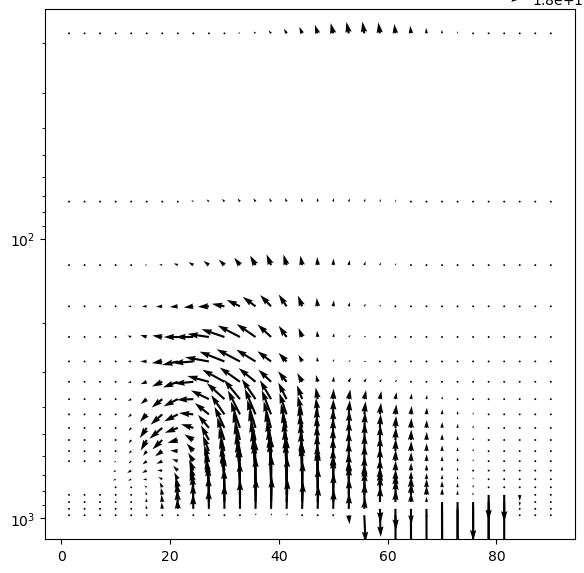

In [47]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1)
set_size(5.3,5.3,ax)
_ = climate.PlotEPfluxArrows(y[32:], p1d[:]/100, 
                         np.nanmean(ep1_PR0_pos[:,:,32:], axis=0), 
                         np.nanmean(ep2_PR0_neg[:,:,32:], axis=0) , 
                         fig, ax, yscale="log")